In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/metro_interstate_traffic_volume_clean.csv", parse_dates=['date_time'])
df.shape

(40575, 8)

In [2]:
df['hour']=df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.day_name()
df[['date_time', 'hour', 'day_of_week']].head()

,date_time,hour,day_of_week
0,2012-10-02 09:00:00,9,Tuesday
1,2012-10-02 10:00:00,10,Tuesday
2,2012-10-02 11:00:00,11,Tuesday
3,2012-10-02 12:00:00,12,Tuesday
4,2012-10-02 13:00:00,13,Tuesday


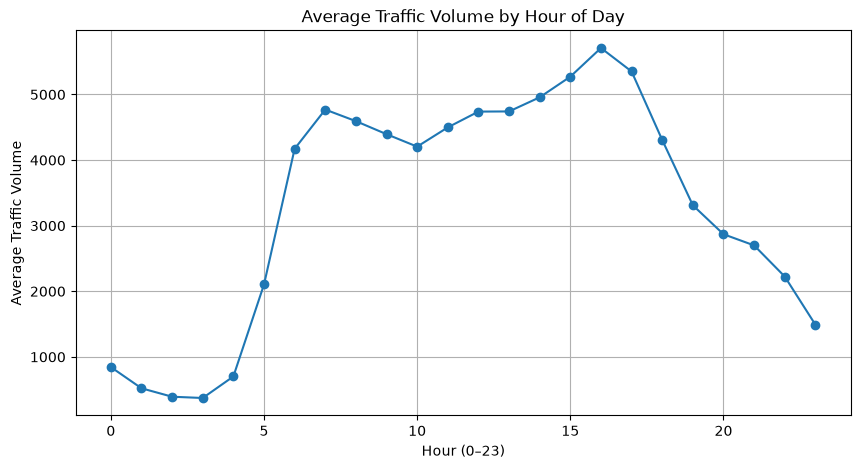

In [3]:
hourly_avg = df.groupby('hour')['traffic_volume'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Traffic Volume by Hour of Day')
plt.xlabel('Hour (0–23)')
plt.ylabel('Average Traffic Volume')
plt.grid(True)
plt.show()

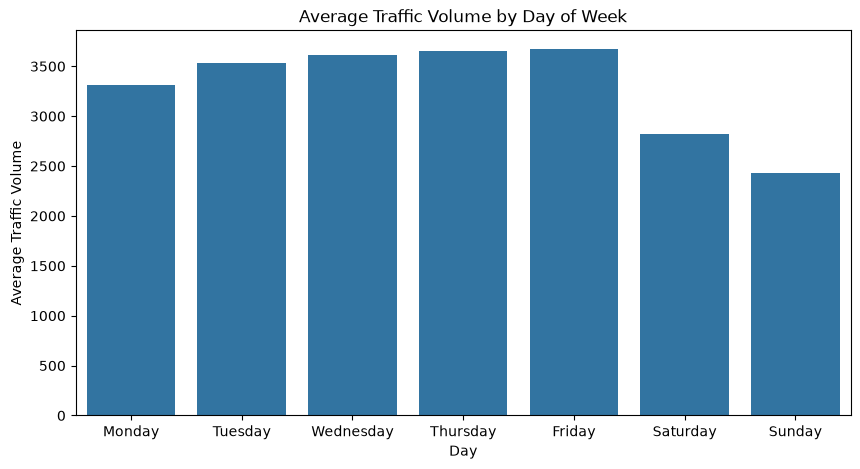

In [4]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily_avg = df.groupby('day_of_week')['traffic_volume'].mean().reindex(day_order)

plt.figure(figsize=(10,5))
sns.barplot(x=daily_avg.index, y=daily_avg.values)
plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Traffic Volume')
plt.show()

In [5]:
df['location'] = 'I-94 Westbound, Minneapolis-St Paul'
df['location'].nunique()

1

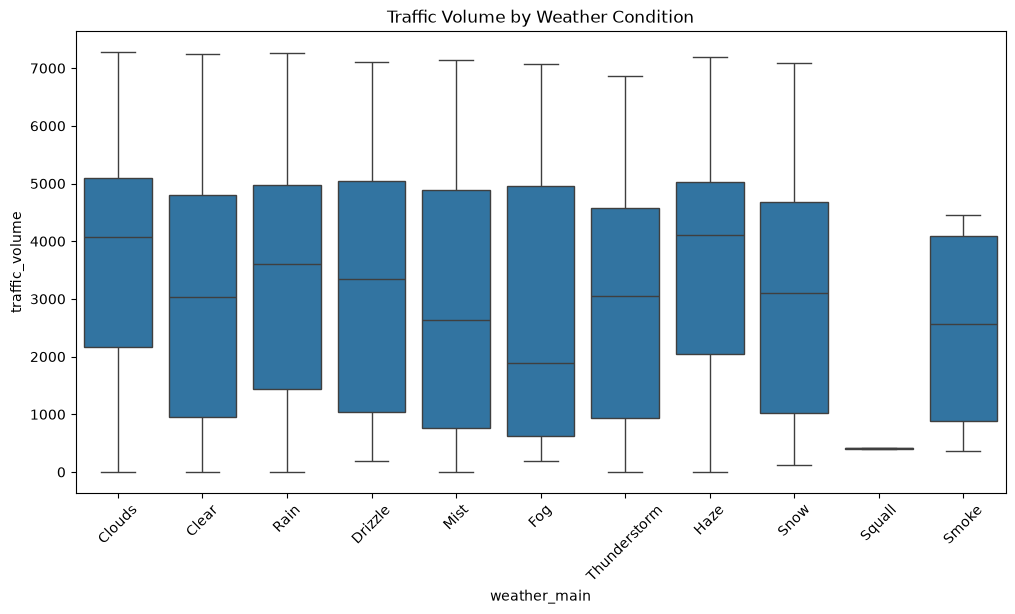

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='weather_main', y='traffic_volume')
plt.title('Traffic Volume by Weather Condition')
plt.xticks(rotation=45)
plt.show()

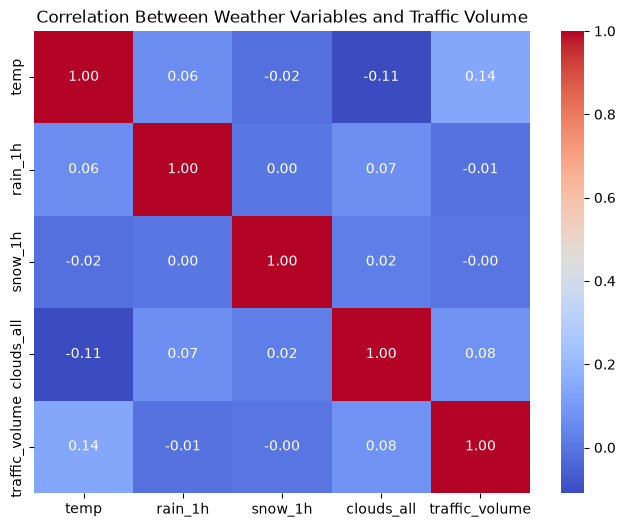

In [7]:
numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Weather Variables and Traffic Volume')
plt.show()

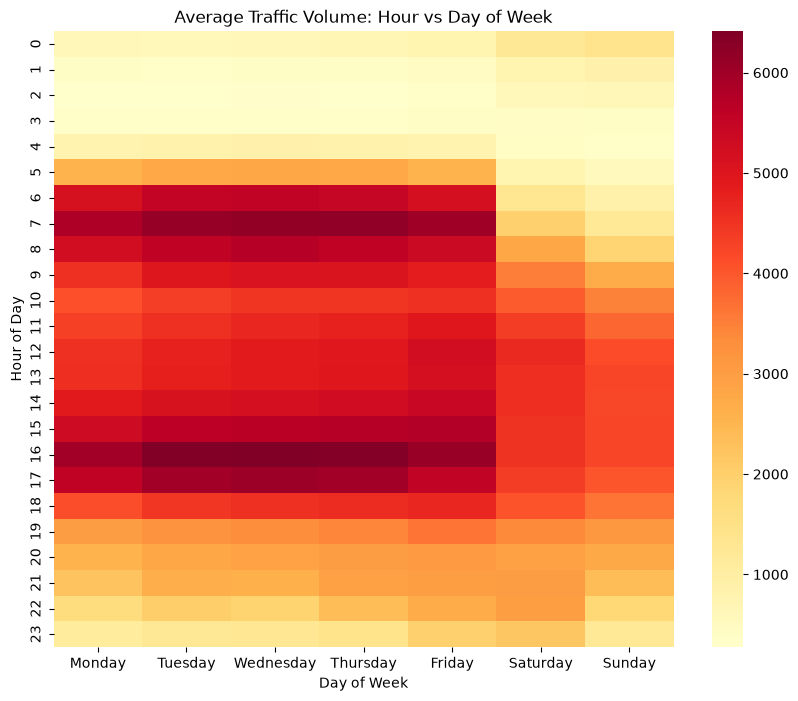

In [8]:
pivot = df.pivot_table(values='traffic_volume', index='hour', columns='day_of_week', aggfunc='mean')
pivot = pivot[day_order]

plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Average Traffic Volume: Hour vs Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.show()

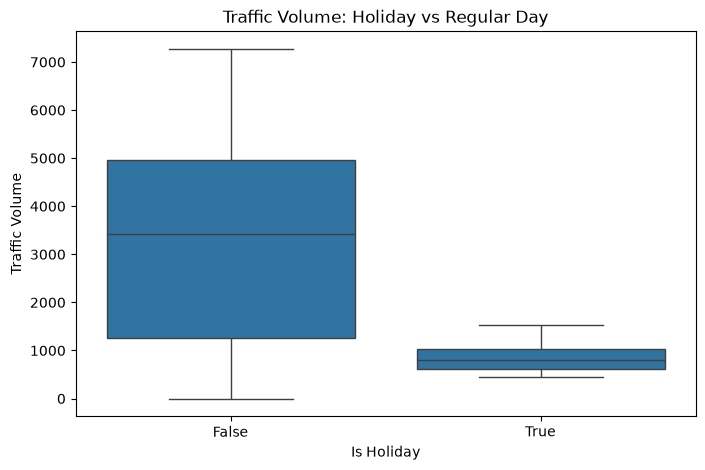

In [9]:
df['is_holiday'] = df['holiday'].notna()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='is_holiday', y='traffic_volume')
plt.title('Traffic Volume: Holiday vs Regular Day')
plt.xlabel('Is Holiday')
plt.ylabel('Traffic Volume')
plt.show()